In [55]:
!pip install kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [56]:
import kagglehub

path = kagglehub.competition_download('scintillation-detector')

print("Path: ", path)

100%|██████████| 13.2M/13.2M [00:00<00:00, 161MB/s]

Extracting files...


Path:  /root/.cache/kagglehub/competitions/scintillation-detector


In [57]:
!mv /root/.cache/kagglehub/competitions/scintillation-detector scintillation-detector

In [58]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

sns.set_style('whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
path_file_data = "/content/scintillation-detector/Run200_Wave_0_1.txt"
df = pd.read_csv(path_file_data, sep=' ', header=None, skipinitialspace=True)
df = df.drop([0, 1, 2, 3, 504], axis=1)
df.columns = list(range(500))
df.head()

print(f'Размер данных: {df.shape}')

Размер данных: (23479, 500)


In [60]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23479 entries, 0 to 23478
Columns: 500 entries, 0 to 499
dtypes: int64(500)
memory usage: 89.6 MB


In [62]:
df.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
0,23479.0,14822.972316,2.805884,14812.0,14821.0,14823.0,14824.0,14834.0
1,23479.0,14822.958474,2.833516,14812.0,14821.0,14823.0,14824.0,14835.0
2,23479.0,14822.970016,2.840755,14812.0,14821.0,14823.0,14825.0,14834.0
3,23479.0,14822.989991,2.852066,14811.0,14821.0,14823.0,14825.0,14835.0
4,23479.0,14823.003961,2.833412,14812.0,14821.0,14823.0,14825.0,14834.0


In [63]:
missing_values = df.isnull().sum()
total_rows = len(df)

missing_data = missing_values[missing_values > 0].to_frame(name="Missing Count")
missing_data["Missing Percentage"] = (missing_data["Missing Count"] / total_rows) * 100

print(missing_data if missing_values.any() else 'no empty')

no empty


In [64]:
print("duplicates:", df.duplicated().sum())

duplicates: 0


Text(0, 0.5, 'bit ADC')

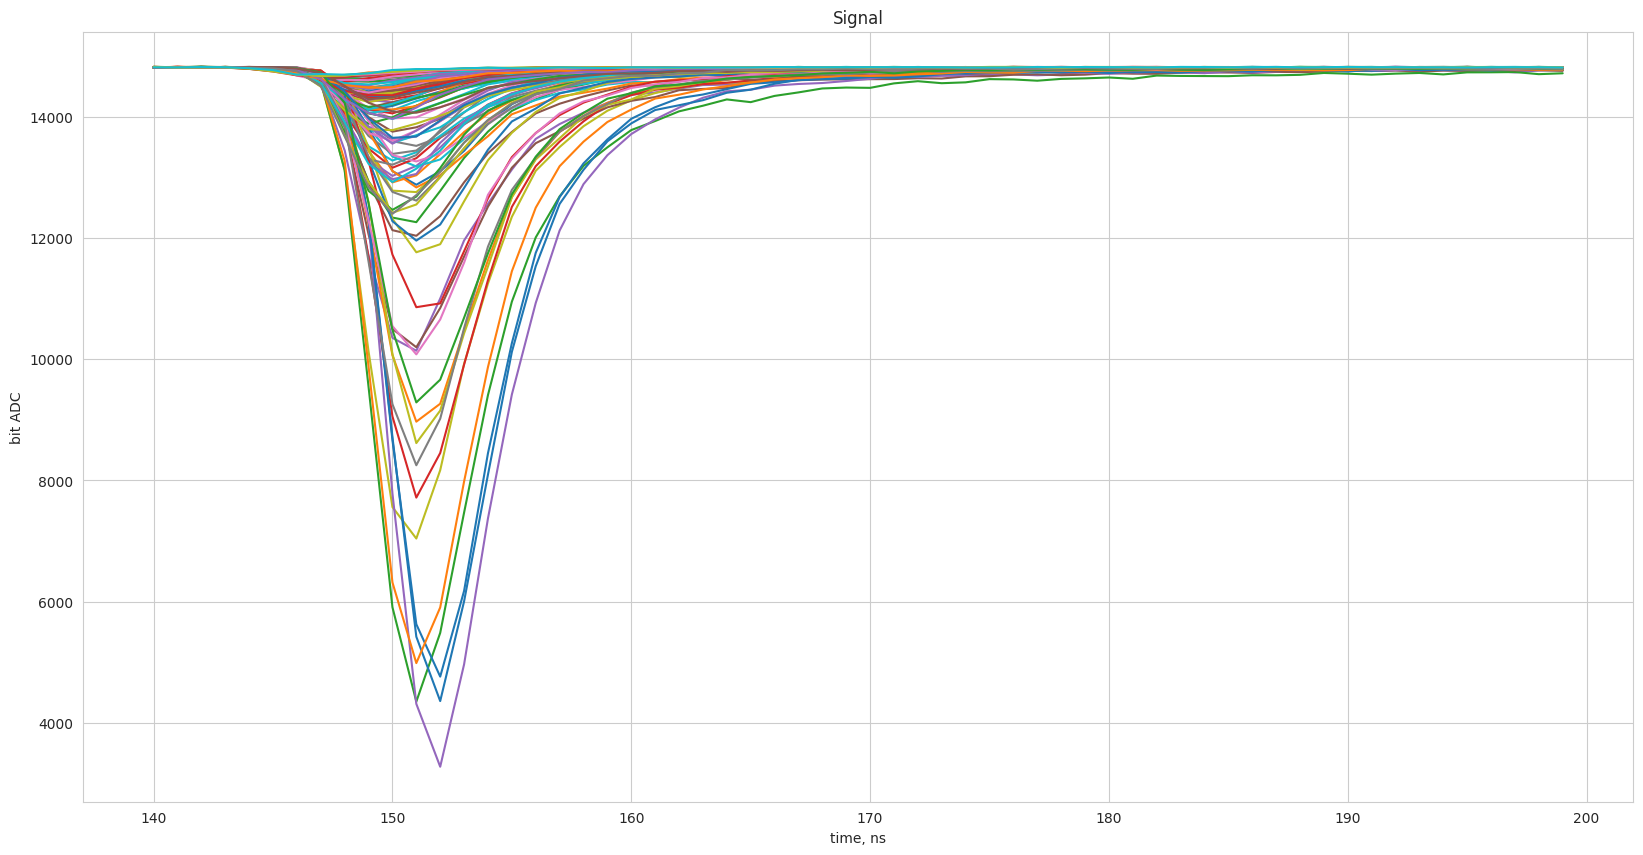

In [65]:
N=range(0,100)
ax = df.T[N][140:200].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")

Text(0, 0.5, 'bit ADC')

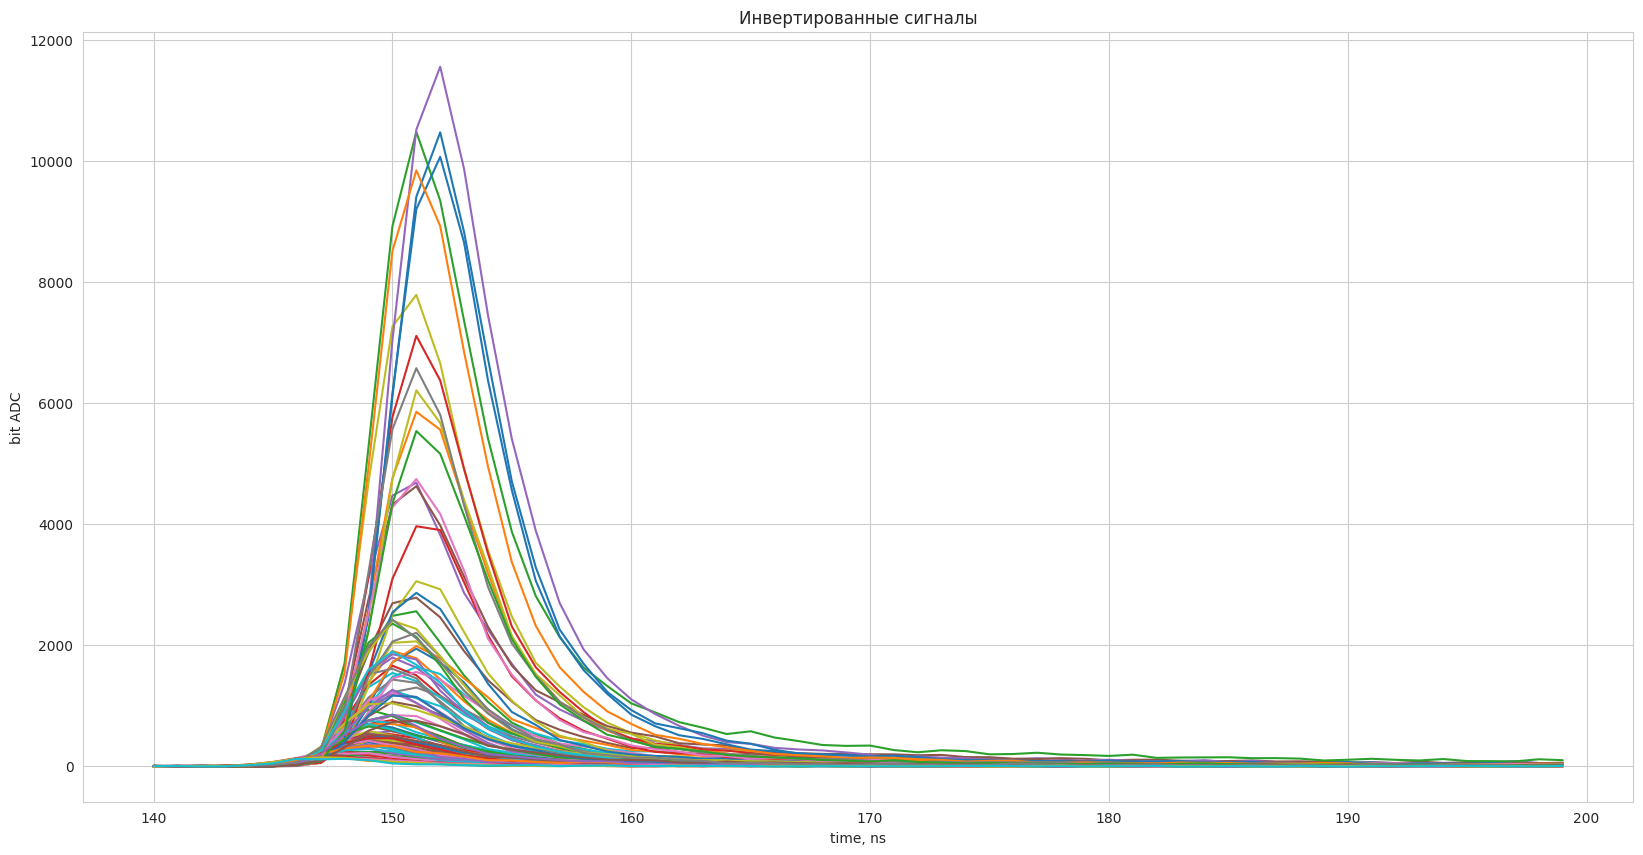

In [66]:
ax = (2**14-df.T[N]-1560)[140:200].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_title('Инвертированные сигналы')
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")

## Подготовка формы сигнала

In [67]:
X = df.astype('float32')
X_signal = (2**14 - X - 1560).to_numpy(dtype=np.float32)

In [68]:
BASELINE_SAMPLES = 140      # объем выборки для оценки базового уровня шума
DETECTION_THRESHOLD = 3.0   # порог обнаружения (в единицах стандартного отклонения шума)
TAIL_POINTS = 3             # минимальное количество последовательных сэмплов ниже порога для фиксации конца события
PEAK_BACKSHIFT = 3          # отступ от максимума сигнала до старта интервала интегрирования
INTEGRATION_WINDOW = 4      # длина узкого интервала для оценки пикового значения


def find_signal_end(y, peak_idx, noise_std):
    """Определяет индекс завершения события по критерию спада ниже порога шума."""
    n_events, n_samples = y.shape
    end_idx = np.full(n_events, n_samples - 1, dtype=np.int32)
    threshold = DETECTION_THRESHOLD * noise_std

    for i in range(n_events):
        run_length = 0
        for j in range(peak_idx[i], n_samples):
            if y[i, j] <= threshold[i]:
                run_length += 1
                if run_length >= TAIL_POINTS:
                    # Фиксируем конец как начало непрерывного спада
                    end_idx[i] = max(j - TAIL_POINTS + 1, peak_idx[i])
                    break
            else:
                run_length = 0
    return end_idx


def integrate_interval(y, peak_idx, end_idx, offset, length=None):
    """
    Вычисляет интеграл сигнала в заданном интервале.
    Если length задан – используется окно фиксированной длины,
    иначе интегрирование производится до конца события (end_idx).
    Отрицательные отсчеты (падения ниже нуля) исключаются из суммы.
    """
    n_events = y.shape[0]
    integral = np.zeros(n_events)

    for i in range(n_events):
        start = peak_idx[i] + offset
        stop = end_idx[i] + 1 if length is None else min(start + length, end_idx[i] + 1)

        if start < stop:
            window = y[i, start:stop]
            # Отсекаем негативную часть для чистоты интегрирования площади
            integral[i] = np.clip(window, 0, None).sum()
    return integral


def build_features(X_inv, RAW_orig):
    """Формирует таблицу физически интерпретируемых признаков на основе инвертированных сигналов."""

    # Оценка фонового шума
    baseline = X_inv[:, :BASELINE_SAMPLES].mean(axis=1)
    noise_std = X_inv[:, :BASELINE_SAMPLES].std(axis=1) + 1e-6

    # Базелинирование (вычитание постоянной составляющей)
    y = X_inv - baseline[:, None]

    # Локализация максимума и его амплитуда
    peak_idx = y.argmax(axis=1).astype(np.int32)
    amplitude = y[np.arange(len(y)), peak_idx].clip(1e-6)

    # Определение границы завершения события
    end_idx = find_signal_end(y, peak_idx, noise_std)

    # Вычисление площадей (интегралов) для широкого и узкого интервалов
    wide_area = integrate_interval(y, peak_idx, end_idx, PEAK_BACKSHIFT) + 1e-6
    narrow_area = integrate_interval(y, peak_idx, end_idx, 0, length=INTEGRATION_WINDOW) + 1e-6

    # Расчет итоговых признаков
    # psd: доля "хвоста" в общей площади (характеризует форму распределения энергии)
    psd = (wide_area - narrow_area) / wide_area

    # tail_length: длительность события после достижения пика
    tail_length = end_idx - peak_idx + 1

    # log_ratio: логарифм отношения пиковой амплитуды к полной площади
    log_ratio = np.log10(amplitude / wide_area)

    # saturated: флаг аномалий (перегрузка АЦП или обрыв сигнала)
    saturated = (amplitude >= 14000) | (RAW_orig == 0).any(axis=1)

    return pd.DataFrame({
        'baseline': baseline,
        'noise_std': noise_std,
        'peak_idx': peak_idx,
        'end_idx': end_idx,
        'amplitude': amplitude,
        'wide_area': wide_area,
        'narrow_area': narrow_area,
        'psd': psd,
        'tail_length': tail_length,
        'log_ratio': log_ratio,
        'saturated': saturated,
    })


features = build_features(X_signal, X)
print('Размер таблицы признаков:', features.shape)
features.head()

Размер таблицы признаков: (23479, 11)


,baseline,noise_std,peak_idx,end_idx,amplitude,wide_area,narrow_area,psd,tail_length,log_ratio,saturated
0,3.035714,2.731852,149,202,529.964294,1900.178468,1622.857179,0.145945,54,-0.554548,False
1,1.742857,2.718643,150,188,1901.257202,4316.257814,6189.028810,-0.433888,39,-0.356067,False
2,2.150000,2.416979,151,200,2557.850098,4580.950196,7160.400392,-0.563082,50,-0.253080,False
3,1.400000,2.776947,149,189,564.599976,1901.799928,1896.399903,0.002839,41,-0.527424,False
4,2.500000,2.676619,150,182,1793.500000,3862.000001,5691.000001,-0.473589,33,-0.333111,False


### Разведочный анализ данных (EDA)

Описательная статистика признаков:
                 mean       std      min       50%        max
amplitude    1835.102  2389.307  104.307   812.807  14824.600
wide_area    4896.082  6055.655   71.357  2306.250  51153.430
psd            -0.232     0.397   -3.850    -0.194      0.416
tail_length    53.303    40.061    8.000    40.000    271.000
noise_std       2.703     0.165    2.087     2.700      9.486
log_ratio      -0.424     0.157   -0.796    -0.417      0.385


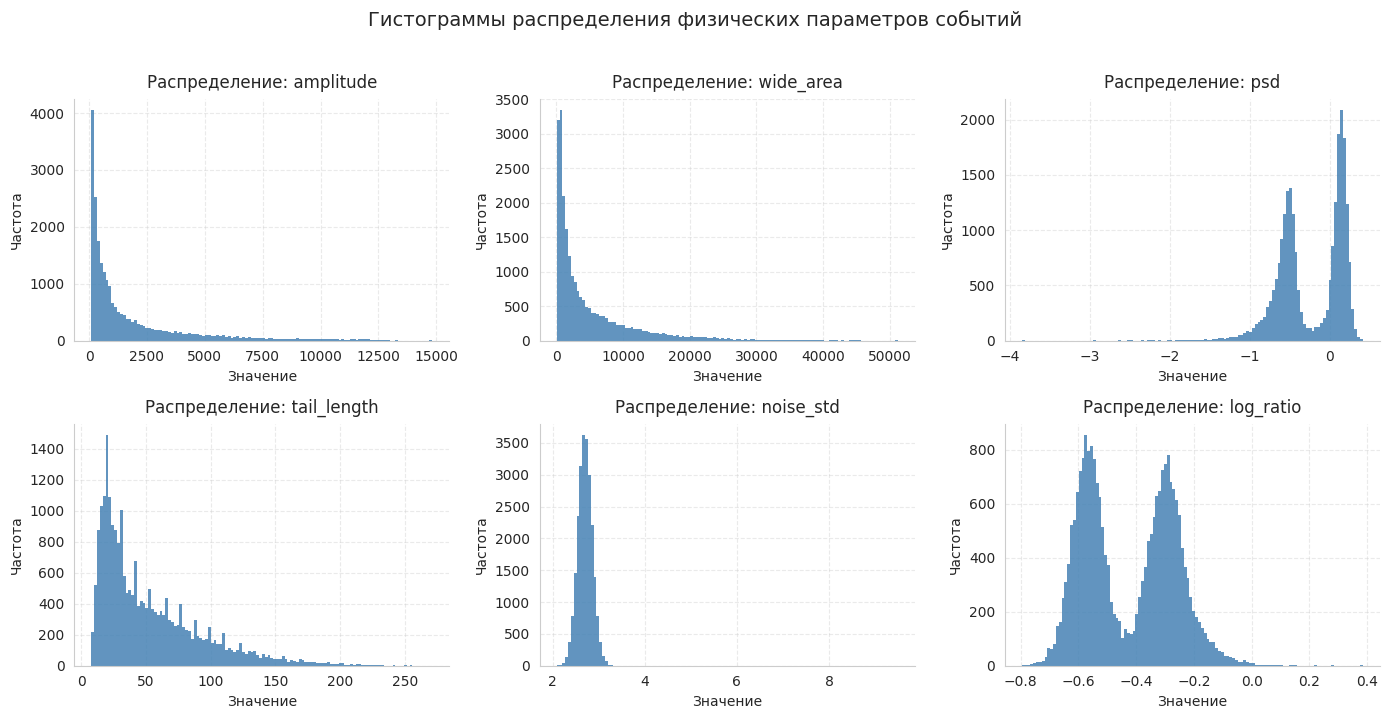

In [69]:
analyzed_features = ['amplitude', 'wide_area', 'psd', 'tail_length', 'noise_std', 'log_ratio']

# Вывод описательной статистики с выбором конкретных метрик
print("Описательная статистика признаков:")
print(features[analyzed_features].describe().T[['mean', 'std', 'min', '50%', 'max']].round(3))

# Настройка размера и стиля фигуры
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for ax, col in zip(axes.ravel(), analyzed_features):
    # Строим гистограмму
    ax.hist(features[col].dropna(), bins=120, color='steelblue', alpha=0.85, edgecolor='none')

    # Научное оформление графиков
    ax.set_title(f'Распределение: {col}', fontsize=12, pad=8)
    ax.set_xlabel('Значение', fontsize=10)
    ax.set_ylabel('Частота', fontsize=10)
    ax.grid(linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Гистограммы распределения физических параметров событий', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

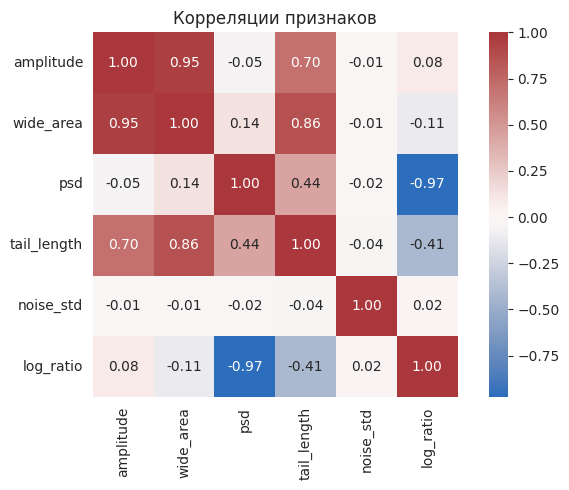

In [70]:
corr = features[analyzed_features].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0, square=True)
plt.title('Корреляции признаков')
plt.tight_layout()
plt.show()

## Вывод
Признаки имеют асимметричное, но физически объяснимое распределение, при этом их роли различаются:
- psd — оптимально для классификации типов частиц
- log_ratio — лучше всего выявляет аномалии
- остальные признаки — описывают масштаб и форму сигналов

## Сравнение моделей кластеризации

In [78]:
main_cols = ['psd', 'log_ratio']
F2 = StandardScaler().fit_transform(features[main_cols].to_numpy())

# Подвыборка 5000 объектов
N = len(F2)
sub_idx = np.random.default_rng(RANDOM_STATE).choice(N, size=min(5000, N), replace=False)
X_sub = F2[sub_idx]

models = {
    'GMM(k=2, full)': GaussianMixture(
        n_components=2,
        covariance_type='full',
        n_init=5,
        random_state=RANDOM_STATE
    ),
    'GMM(k=2, tied)': GaussianMixture(
        n_components=2,
        covariance_type='tied',
        n_init=5,
        random_state=RANDOM_STATE
    ),
    'GMM(k=2, diag)': GaussianMixture(
        n_components=2,
        covariance_type='diag',
        n_init=5,
        random_state=RANDOM_STATE
    ),
    'GMM(k=3, full)': GaussianMixture(
        n_components=3,
        covariance_type='full',
        n_init=5,
        random_state=RANDOM_STATE
    ),
    'KMeans(k=2)': KMeans(
        n_clusters=2,
        n_init=10,
        random_state=RANDOM_STATE
    ),
    'KMeans(k=3)': KMeans(
        n_clusters=3,
        n_init=10,
        random_state=RANDOM_STATE
    ),
    'KMeans(k=4)': KMeans(
        n_clusters=4,
        n_init=10,
        random_state=RANDOM_STATE
    ),
    'Agglom(k=2, ward)': AgglomerativeClustering(
        n_clusters=2,
        linkage='ward'
    ),
    'Agglom(k=2, avg)': AgglomerativeClustering(
        n_clusters=2,
        linkage='average'
    ),
    'Agglom(k=3, ward)': AgglomerativeClustering(
        n_clusters=3,
        linkage='ward'
    ),
}

results = []
for name, model in models.items():
    labels_pred = model.fit_predict(X_sub)
    sil = silhouette_score(X_sub, labels_pred)
    db = davies_bouldin_score(X_sub, labels_pred)
    results.append((name, sil, db))

results_df = pd.DataFrame(results, columns=['Model', 'Silhouette', 'Davies-Bouldin'])
print(results_df.sort_values('Silhouette', ascending=False).to_string(index=False))

            Model  Silhouette  Davies-Bouldin
      KMeans(k=2)    0.739436        0.350015
   GMM(k=2, tied)    0.739357        0.350178
Agglom(k=2, ward)    0.735942        0.348924
   GMM(k=2, diag)    0.728362        0.350889
   GMM(k=2, full)    0.720221        0.355052
      KMeans(k=3)    0.652132        0.565792
 Agglom(k=2, avg)    0.640575        0.436224
   GMM(k=3, full)    0.630702        1.000942
Agglom(k=3, ward)    0.612044        0.609835
      KMeans(k=4)    0.518439        0.702049


## Отделение аномальных событий

In [79]:
LR_QUANTILE = 0.01
SAT_QUANTILE = 0.995

lr = features['log_ratio'].to_numpy()
amp = features['amplitude'].to_numpy()

q_low, q_high = np.quantile(lr, [LR_QUANTILE, 1 - LR_QUANTILE])
sat_thr = np.quantile(amp, SAT_QUANTILE)

lr_mask = (lr < q_low) | (lr > q_high)
sat_mask = amp >= sat_thr

zero_mask = np.all(X_signal == 0, axis=1)

anomaly_mask = lr_mask | sat_mask | zero_mask

print(f"Anomalies: {anomaly_mask.mean()*100:.2f}%")

print(f'Аномалий: {anomaly_mask.sum()} ({anomaly_mask.mean()*100:.1f}%)')
print(f'\tпо насыщению: {sat_mask.sum()}')
print(f'\tпо log_ratio:  {lr_mask.sum()}')

Anomalies: 2.50%
Аномалий: 588 (2.5%)
	по насыщению: 118
	по log_ratio:  470


## Кластеризация нормальных сигналов с помощью KMeans

In [80]:
normal_idx = np.where(~anomaly_mask)[0]
F2_norm = F2[normal_idx]

kmeans = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE)
lab_norm = kmeans.fit_predict(F2_norm)

mean_psd_per_cluster = [
    features['psd'].to_numpy()[normal_idx][lab_norm == c].mean()
    for c in range(2)
]
neutron_cluster = int(np.argmax(mean_psd_per_cluster))
print(f'Нейтронный кластер: {neutron_cluster}, средние psd: {[round(v, 3) for v in mean_psd_per_cluster]}')

labels = np.full(N, -1, dtype=int)
for i, idx in enumerate(normal_idx):
    labels[idx] = 1 if lab_norm[i] == neutron_cluster else 0
labels[anomaly_mask] = 2

print('Распределение по классам:')
print(pd.Series(labels).value_counts().sort_index())

Нейтронный кластер: 0, средние psd: [np.float64(0.125), np.float64(-0.576)]
Распределение по классам:
0    11402
1    11489
2      588
Name: count, dtype: int64


## Вывод
Кластеризация успешно разделила смешанное поле излучения (11 402 гамма-квантов, 11 489 нейтронов, 588 аномалий). Физика процессов подтверждается значениями PSD: нейтроны имеют высокое среднее (0.125) из-за медленной компоненты импульса, а гамма-кванты — низкое (-0.576) из-за быстрого сигнала. Предварительная фильтрация аномалий по log_ratio и насыщению АЦП предотвратила искажение центров кластеров, обеспечив высокую точность разделения основных частиц.

## Визуализация результатов

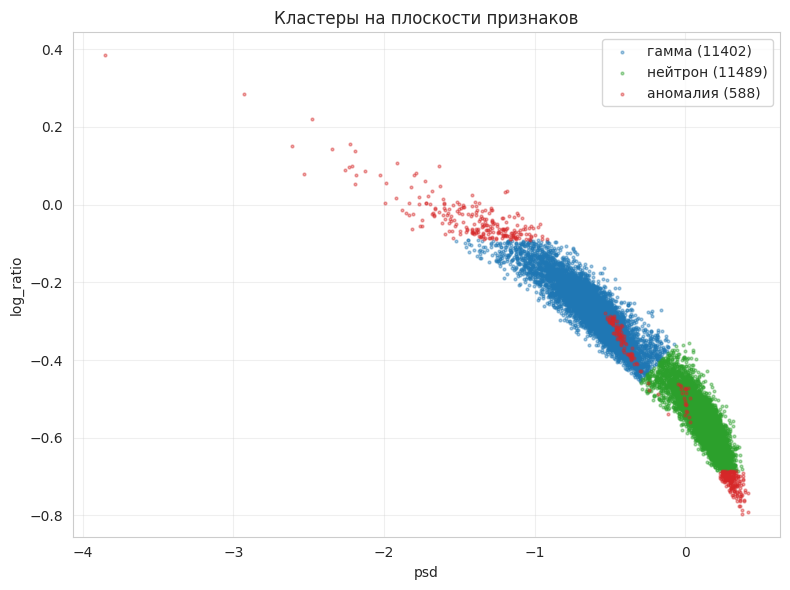

In [81]:
colors = {0: 'tab:blue', 1: 'tab:green', 2: 'tab:red'}
names = {0: 'гамма', 1: 'нейтрон', 2: 'аномалия'}
plt.figure(figsize=(8, 6))

for c in [0, 1, 2]:
    mask = (labels == c)

    plt.scatter(
        features['psd'][mask],
        features['log_ratio'][mask],
        s=4, alpha=0.4,
        c=colors[c],
        label=f'{names[c]} ({mask.sum()})'
    )

plt.xlabel('psd')
plt.ylabel('log_ratio')
plt.title('Кластеры на плоскости признаков')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

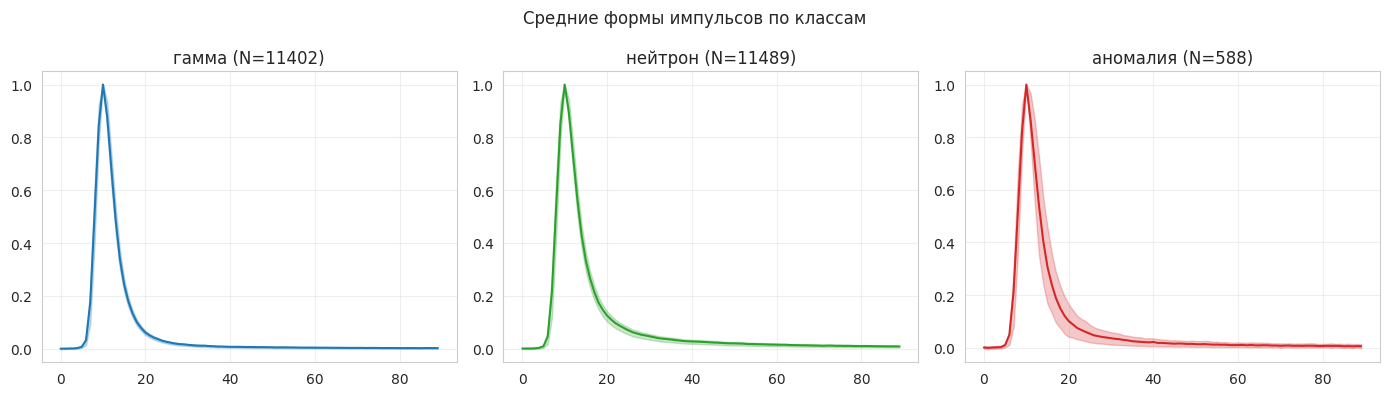

In [82]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, c in zip(axes, [0, 1, 2]):

    mask = (labels == c)
    if mask.sum() == 0:
        continue

    waves_c = X_signal[mask]

    baseline = waves_c[:, :BASELINE_SAMPLES].mean(axis=1, keepdims=True)
    sub = waves_c - baseline

    peaks = sub.argmax(axis=1)

    win = 80
    aligned = []

    for i in range(min(2000, len(sub))):
        p = peaks[i]

        a = max(0, p - 10)
        b = min(sub.shape[1], p + win)

        seg = sub[i, a:b]

        if len(seg) < 20:
            continue

        seg = seg / (seg.max() + 1e-9)

        if len(seg) == (win + 10):
            aligned.append(seg)

    aligned = np.array(aligned)

    if len(aligned) == 0:
        continue

    ax.plot(aligned.mean(axis=0), color=colors[c])
    ax.fill_between(
        np.arange(aligned.shape[1]),
        np.percentile(aligned, 25, axis=0),
        np.percentile(aligned, 75, axis=0),
        color=colors[c], alpha=0.25
    )

    ax.set_title(f'{names[c]} (N={mask.sum()})')
    ax.grid(alpha=0.3)

plt.suptitle('Средние формы импульсов по классам')
plt.tight_layout()
plt.show()

In [83]:
def reorder_by_appearance(labels_array):
    mapping = {}
    new_labels = np.empty_like(labels_array)
    next_label = 0
    for i, val in enumerate(labels_array):
        if val not in mapping:
            mapping[val] = next_label
            next_label += 1
        new_labels[i] = mapping[val]
    return new_labels

final_labels = reorder_by_appearance(labels)

submission = pd.DataFrame({'index': np.arange(N), 'cluster': final_labels})
submission.to_csv('submission.csv', index=False)
print('Файл submission.csv сохранён.')
print(submission.head())

Файл submission.csv сохранён.
   index  cluster
0      0        0
1      1        1
2      2        1
3      3        0
4      4        1
